In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Read in coordinates 
array_A  = np.array([
    [ 63.  ,   0.  ,   0.  ],
    [ 44.55,  44.55,   0.  ],
    [  0.  ,  63.  ,   0.  ],
    [-44.55,  44.55,   0.  ],
    [-63.  ,   0.  ,   0.  ],
    [-44.55, -44.55,   0.  ],
    [ -0.  , -63.  ,   0.  ],
    [ 44.55, -44.55,   0.  ]
    ])
array_B = np.array([
    [ 63.  ,   0.  , -38.5 ],
    [ 44.55,  44.55, -38.5 ],
    [  0.  ,  63.  , -38.5 ],
    [-44.55,  44.55, -38.5 ],
    [-63.  ,   0.  , -38.5 ],
    [-44.55, -44.55, -38.5 ],
    [ -0.  , -63.  , -38.5 ],
    [ 44.55, -44.55, -38.5 ]
    ]) 
array_C = np.array([
    [ 47.00,   0.00, -68.50],
    [ 79.00,   0.00, -68.50],
    [ 55.86,  55.86, -68.50],
    [ 33.23,  33.23, -68.50],
    [  0.00,  47.00, -68.50],
    [  0.00,  79.00, -68.50],
    [-55.86,  55.86, -68.50],
    [-33.23,  33.23, -68.50],
    [-47.00,   0.00, -68.50],
    [-79.00,   0.00, -68.50],
    [-55.86, -55.86, -68.50],
    [-33.23, -33.23, -68.50],
    [  0.00, -47.00, -68.50],
    [  0.00, -79.00, -68.50],
    [ 55.86, -55.86, -68.50],
    [ 33.23, -33.23, -68.50],
    ])
radius_A = 24.0
radius_B= 14.0
radius_C = 16.0
radius = {
    'A': radius_A,
    'B': radius_B,
    'C': radius_C
}
# define copy numbers 
copy_numbers = {
    'A': 8,
    'B': 8,
    'C': 16
}

In [3]:
# Visualize the coordinates using 3D matplotlib 
def visualize_coordinates(array_a, array_b, array_c):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    # Create a 3D scatter plot
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(array_a[:, 0], array_a[:, 1], array_a[:, 2], c='r', s=radius_A**2, label='A')
    ax.scatter(array_b[:, 0], array_b[:, 1], array_b[:, 2], c='g', s=radius_B**2, label='B')
    ax.scatter(array_c[:, 0], array_c[:, 1], array_c[:, 2], c='b', s=radius_C**2, label='C')
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.set_title('3D Visualization of Coordinates')
    ax.legend()
    plt.show()

rotated_array:
 [[ 62.98618306   0.           1.31937245]
 [ 44.54022945  44.55         0.93298481]
 [  0.          63.           0.        ]
 [-44.54022945  44.55        -0.93298481]
 [-62.98618306   0.          -1.31937245]
 [-44.54022945 -44.55        -0.93298481]
 [  0.         -63.           0.        ]
 [ 44.54022945 -44.55         0.93298481]] 
 array_A:
 [[ 63.     0.     0.  ]
 [ 44.55  44.55   0.  ]
 [  0.    63.     0.  ]
 [-44.55  44.55   0.  ]
 [-63.     0.     0.  ]
 [-44.55 -44.55   0.  ]
 [ -0.   -63.     0.  ]
 [ 44.55 -44.55   0.  ]]


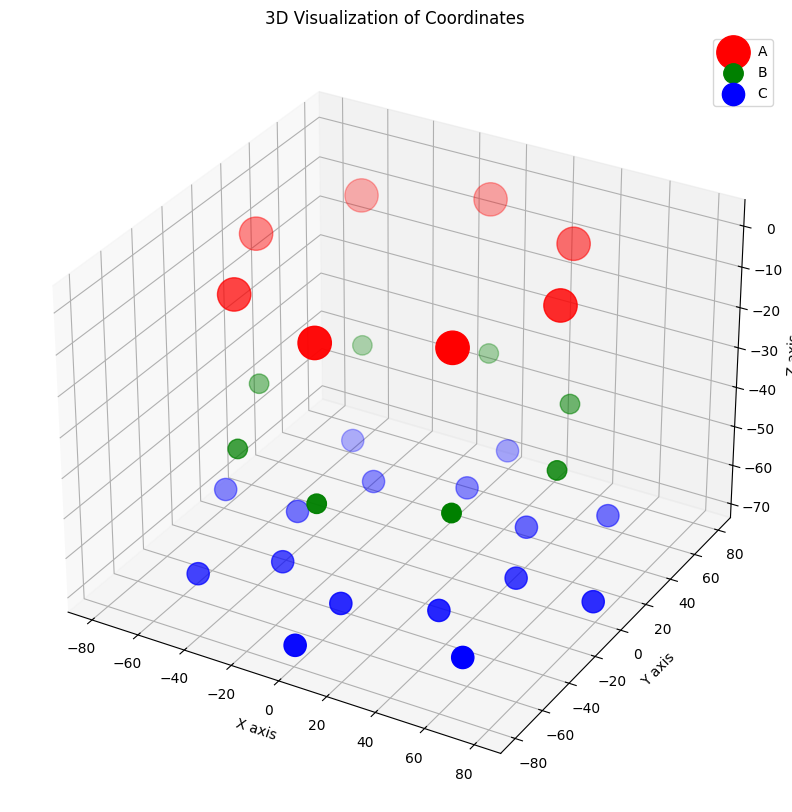

move_particles:
 [[ 47.           0.         -68.5       ]
 [ 79.           0.         -68.5       ]
 [ 55.86        55.86       -68.5       ]
 [ 33.23        33.23       -68.5       ]
 [  0.          47.         -68.5       ]
 [ -0.36060584  87.28010665 -59.75356315]
 [-55.86        55.86       -68.5       ]
 [-33.23        33.23       -68.5       ]
 [-47.           0.         -68.5       ]
 [-82.66207082   7.47247535 -60.22010356]
 [-64.03850153 -50.93973353 -71.39665859]
 [-33.23       -33.23       -68.5       ]
 [  0.         -47.         -68.5       ]
 [ -3.15659812 -72.69168775 -58.89081719]
 [ 55.86       -55.86       -68.5       ]
 [ 33.76827614 -39.11782173 -59.63226354]] 
 array_C:
 [[ 47.     0.   -68.5 ]
 [ 79.     0.   -68.5 ]
 [ 55.86  55.86 -68.5 ]
 [ 33.23  33.23 -68.5 ]
 [  0.    47.   -68.5 ]
 [  0.    79.   -68.5 ]
 [-55.86  55.86 -68.5 ]
 [-33.23  33.23 -68.5 ]
 [-47.     0.   -68.5 ]
 [-79.     0.   -68.5 ]
 [-55.86 -55.86 -68.5 ]
 [-33.23 -33.23 -68.5 ]
 [  0.   -

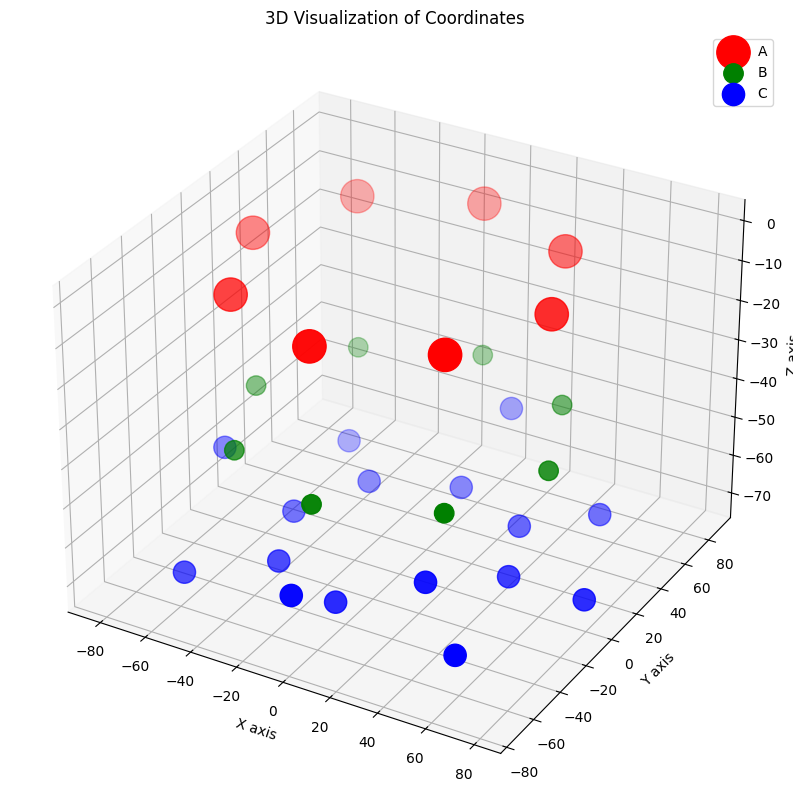

In [7]:
# Create perturbations
def rotate_ring(array, angle):
    """Rotate the ring by a given angle around the Y-axis."""
    rotation_matrix = np.array([
        [np.cos(angle), 0, np.sin(angle)],
        [0, 1, 0],
        [-np.sin(angle), 0, np.cos(angle)]
    ])
    return np.dot(array, rotation_matrix)

def shift_ring(array, shift):
    """Shift the ring by a given vector."""
    return array + shift

def move_particles_randomly(array, num_particles, shift):
    """Move particles randomly within a specified range."""
    # randomly select which subset of particles to perturb
    perturbation_indices = np.random.choice(array.shape[0], num_particles, replace=False)
    # create a copy of the array to avoid modifying the original
    perturbed_array = array.copy()
    # apply perturbations to the selected particles
    for index in perturbation_indices:
        # choose a random coordinate shift
        random_shift = np.random.uniform(-shift, shift, size=3)
        perturbed_array[index] += random_shift
    # return the perturbed array
    return perturbed_array

# run these and visualize the results
rotated_array = rotate_ring(array_A, np.pi/150.0)
print("rotated_array:\n", rotated_array, "\n", "array_A:\n", array_A)
visualize_coordinates(rotated_array, array_B, array_C)
#visualize_coordinates(array_A, array_B, array_C)

move_particles = move_particles_randomly(array_C, 5, 10.0)
print("move_particles:\n", move_particles, "\n", "array_C:\n", array_C)
visualize_coordinates(array_A, array_B, move_particles)

In [8]:
# Create a pdb format for the particle coordinates and save to file 
# create a directory called 'pdb_files' if it doesn't exist
import os
if not os.path.exists('pdb_files'):
    os.makedirs('pdb_files')
# Function that will generate perturbed coordinates and save them in pdb format
def save_coordinates_to_pdb(df, filename, radius):
    """Save coordinates to a PDB file.
    The dataframe should have columns 'x', 'y', 'z', and 'type'.
    the radius is a dictionary with particle types as keys and their radii as values.
    """
    with open(filename, 'w') as f:
        for i, row in df.iterrows():
            x, y, z = row['x'], row['y'], row['z']
            particle_type = row['type']
            radius_value = radius[particle_type]
            # Proper PDB format with correct column positioning
            f.write(f"ATOM  {i+1:5d}  {particle_type:<2}  UNK A   1    {x:8.3f}{y:8.3f}{z:8.3f}  1.00{radius_value:6.2f}           {particle_type}\n")
        f.write("END\n")

# Add this import at the top with your other imports
import RMF

def save_coordinates_to_rmf(df, filename, radius):
    """Save coordinates to an RMF3 file with proper radius information.
    The dataframe should have columns 'x', 'y', 'z', and 'type'.
    the radius is a dictionary with particle types as keys and their radii as values.
    """
    import os
    import time
    
    # Remove existing file if it exists to avoid conflicts
    if os.path.exists(filename):
        try:
            os.remove(filename)
            time.sleep(0.1)  # Small delay to ensure file is fully released
        except OSError as e:
            print(f"Warning: Could not remove existing file {filename}: {e}")
    
    # Try to close any existing RMF handles (cleanup)
    try:
        import gc
        gc.collect()  # Force garbage collection
    except:
        pass
    
    rmf_file = None
    try:
        # Create RMF file with a unique temporary name first
        temp_filename = filename + ".tmp"
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
        
        rmf_file = RMF.create_rmf_file(temp_filename)
        
        # Create root node and model
        root = rmf_file.get_root_node()
        model = root.add_child("model", RMF.REPRESENTATION)
        
        # Add particle factory
        pf = RMF.ParticleFactory(rmf_file)
        
        # Create particles
        for i, row in df.iterrows():
            x, y, z = row['x'], row['y'], row['z']
            particle_type = row['type']
            radius_value = radius[particle_type]
            
            # Create particle node
            particle_node = model.add_child(f"{particle_type}_{i}", RMF.REPRESENTATION)
            
            # Set particle data
            particle_data = pf.get(particle_node)
            particle_data.set_coordinates([x, y, z])
            particle_data.set_radius(radius_value)
            particle_data.set_mass(1.0)  # Set a default mass
            
            # Optionally set particle type/name
            particle_node.set_name(f"{particle_type}_{i}")
        
        # Add frame
        rmf_file.add_frame("frame0", RMF.FRAME)
        rmf_file.flush()
        
        # Close the file properly
        rmf_file.close()
        rmf_file = None
        
        # Move temp file to final location
        if os.path.exists(filename):
            os.remove(filename)
        os.rename(temp_filename, filename)
        
        print(f"RMF3 file saved: {filename}")
        
    except Exception as e:
        print(f"Error creating RMF file: {e}")
        # Clean up temp file if it exists
        temp_filename = filename + ".tmp"
        if os.path.exists(temp_filename):
            try:
                os.remove(temp_filename)
            except:
                pass
        raise
    finally:
        # Ensure file is always closed
        if rmf_file is not None:
            try:
                rmf_file.close()
            except:
                pass

# Alternative: Create a simpler version that skips RMF if there are issues
def save_coordinates_safe(df, base_filename, radius):
    """Save coordinates, trying RMF but falling back to PDB only if needed."""
    pdb_filename = base_filename + '.pdb'
    rmf_filename = base_filename + '.rmf3'
    
    # Always save PDB
    save_coordinates_to_pdb(df, pdb_filename, radius)
    print(f"PDB file saved: {pdb_filename}")
    
    # Try to save RMF
    try:
        save_coordinates_to_rmf(df, rmf_filename, radius)
    except Exception as e:
        print(f"Failed to save RMF file: {e}")
        print("Continuing with PDB file only...")

# Update your existing code to save both formats
# perturbation_1, rotate the ring of A by 10 degrees
perturbed_array_A = rotate_ring(array_A, np.pi/20)
# merge the perturbed coordinates with original B and C arrays
perturbed_array_A = np.vstack((perturbed_array_A, array_B, array_C))
# create a dataframe for the perturbed coordinates
perturbed_df_A = pd.DataFrame(perturbed_array_A, columns=['x', 'y', 'z'])
# attach a column with particle type
perturbed_df_A['type'] = ['A'] * 8 + ['B'] * 8 + ['C'] * 16

# Use the safer version
save_coordinates_safe(perturbed_df_A, 'pdb_files/perturbed_A', radius)

perturbed_array_B = shift_ring(array_B, np.array([25.0, -10.0, 0.0]))
# merge the perturbed coordinates with original A and C arrays
perturbed_array_B = np.vstack((array_A, perturbed_array_B, array_C))
# create a dataframe for the perturbed coordinates
perturbed_df_B = pd.DataFrame(perturbed_array_B, columns=['x', 'y', 'z'])
# attach a column with particle type
perturbed_df_B['type'] = ['A'] * 8 + ['B'] * 8 + ['C'] * 16
# Save perturbed coordinates for B
save_coordinates_safe(perturbed_df_B, 'pdb_files/perturbed_B', radius)

# merge the perturbed C coordinates 
perturbed_array_C = move_particles_randomly(array_C, 5, 20.0)
# merge the perturbed coordinates with original A and B arrays
perturbed_array_C = np.vstack((array_A, array_B, perturbed_array_C))
# create a dataframe for the perturbed coordinates
perturbed_df_C = pd.DataFrame(perturbed_array_C, columns=['x', 'y', 'z'])
# attach a column with particle type
perturbed_df_C['type'] = ['A'] * 8 + ['B'] * 8 + ['C'] * 16
# Save perturbed coordinates for C
save_coordinates_safe(perturbed_df_C, 'pdb_files/perturbed_C', radius)


PDB file saved: pdb_files/perturbed_A.pdb
Error creating RMF file:  "Can't create file" in file "pdb_files/perturbed_A.rmf3.tmp"
Failed to save RMF file:  "Can't create file" in file "pdb_files/perturbed_A.rmf3.tmp"
Continuing with PDB file only...
PDB file saved: pdb_files/perturbed_B.pdb
Error creating RMF file:  "Can't create file" in file "pdb_files/perturbed_B.rmf3.tmp"
Failed to save RMF file:  "Can't create file" in file "pdb_files/perturbed_B.rmf3.tmp"
Continuing with PDB file only...
PDB file saved: pdb_files/perturbed_C.pdb
Error creating RMF file:  "Can't create file" in file "pdb_files/perturbed_C.rmf3.tmp"
Failed to save RMF file:  "Can't create file" in file "pdb_files/perturbed_C.rmf3.tmp"
Continuing with PDB file only...


In [9]:
import RMF
try:
    rmf_file = RMF.create_rmf_file('test.rmf3')
    rmf_file.close()
    print("Successfully created test.rmf3")
except Exception as e:
    print(f"Failed to create test.rmf3: {e}")

Successfully created test.rmf3


In [10]:
import IMP
import IMP.pmi
import IMP.atom
import IMP.algebra
import IMP.core
import IMP.pmi.output
import numpy as np
import pandas as pd

def create_imp_model_and_save_to_rmf(df, radius, rmf_filename):
    """
    Create an IMP model from particle coordinates and radii, and save it to an RMF file.
    
    Parameters:
    - df: DataFrame with columns 'x', 'y', 'z', and 'type'.
    - radius: Dictionary mapping particle types to their radii (e.g., {'A': 5.0, 'B': 3.0}).
    - rmf_filename: Path to the output RMF file (e.g., 'output.rmf').
    """
    # Create an IMP model
    model = IMP.Model()
    
    # Create the root particle and set up its hierarchy
    root = IMP.Particle(model)
    root_h = IMP.atom.Hierarchy.setup_particle(root)
    root.set_name("root")
    
    # Add each particle to the model and hierarchy
    for i, row in df.iterrows():
        x, y, z = row['x'], row['y'], row['z']
        particle_type = row['type']
        radius_value = radius[particle_type]
        
        # Create a particle
        p = IMP.Particle(model)
        p.set_name(f"{particle_type}_{i}")
        
        # Set up hierarchy for the particle
        h = IMP.atom.Hierarchy.setup_particle(p)
        
        # Set coordinates and radius
        sphere = IMP.algebra.Sphere3D([x, y, z], radius_value)
        IMP.core.XYZR.setup_particle(p, sphere)
        
        # IMPORTANT: Add mass to the particle
        IMP.atom.Mass.setup_particle(p, 1.0)  # Set mass to 1.0
        
        # Add the child hierarchy to the root hierarchy
        root_h.add_child(h)
    
    # Create output and save RMF file outside the loop
    output = IMP.pmi.output.Output()
    output.init_rmf(rmf_filename, [root_h])  
    output.write_rmf(rmf_filename)
    output.close_rmf(rmf_filename)
    
    print(f"RMF file created: {rmf_filename}")
    return model, root_h

# Test with your actual data
create_imp_model_and_save_to_rmf(perturbed_df_A, radius, "pdb_files/perturbed_A_imp.rmf3")
create_imp_model_and_save_to_rmf(perturbed_df_B, radius, "pdb_files/perturbed_B_imp.rmf3")
create_imp_model_and_save_to_rmf(perturbed_df_C, radius, "pdb_files/perturbed_C_imp.rmf3")

RMF file created: pdb_files/perturbed_A_imp.rmf3
RMF file created: pdb_files/perturbed_B_imp.rmf3
RMF file created: pdb_files/perturbed_C_imp.rmf3


("Model 2", "root" )

In [15]:
# ...existing code...
def radius_to_mass(radius_value, scale=1.0):
    # Relative mass is enough for CCC-based fitting
    return scale * (radius_value ** 3/100)

def create_imp_model_and_save_to_rmf(df, radius, rmf_filename, mass_scale=1.0):
    model = IMP.Model()
    root = IMP.Particle(model)
    root_h = IMP.atom.Hierarchy.setup_particle(root)
    root.set_name("root")

    for i, row in df.iterrows():
        x, y, z = row['x'], row['y'], row['z']
        particle_type = row['type']
        radius_value = radius[particle_type]
        mass_value = radius_to_mass(radius_value, scale=mass_scale)

        p = IMP.Particle(model)
        p.set_name(f"{particle_type}_{i}")
        h = IMP.atom.Hierarchy.setup_particle(p)

        sphere = IMP.algebra.Sphere3D([x, y, z], radius_value)
        IMP.core.XYZR.setup_particle(p, sphere)

        # IMPORTANT: now mass depends on radius
        IMP.atom.Mass.setup_particle(p, mass_value)

        root_h.add_child(h)

    output = IMP.pmi.output.Output()
    output.init_rmf(rmf_filename, [root_h])
    output.write_rmf(rmf_filename)
    output.close_rmf(rmf_filename)

    print(f"RMF file created: {rmf_filename}")
    return model, root_h
# ...existing code...
# Test with your actual data
create_imp_model_and_save_to_rmf(perturbed_df_A, radius, "pdb_files/perturbed_A_new_imp.rmf3")
create_imp_model_and_save_to_rmf(perturbed_df_B, radius, "pdb_files/perturbed_B_new_imp.rmf3")
create_imp_model_and_save_to_rmf(perturbed_df_C, radius, "pdb_files/perturbed_C_new_imp.rmf3")

RMF file created: pdb_files/perturbed_A_new_imp.rmf3
RMF file created: pdb_files/perturbed_B_new_imp.rmf3
RMF file created: pdb_files/perturbed_C_new_imp.rmf3


("Model 17", "root" )